In [ ]:
import pandas as pd

# ==============================
# STEP 1: Charger Excel
# ==============================
df = pd.read_excel("data.xlsx")

df.to_csv("data.csv", index=False)

print("\n===== STEP 1 DONE =====")


===== STEP 1 DONE =====


In [2]:
# ==============================
# STEP 2: Extraire un seul puits
# ==============================
well_name = "TFT-302"
df_well = df[df["WELL"] == well_name].copy()

df_well.to_csv("step2_single_well.csv", index=False)

print("\n===== STEP 2 DONE =====")


===== STEP 2 DONE =====


In [3]:
# ==============================
# STEP 3: Préparer les dates
# ==============================
df_well["DATE"] = pd.to_datetime(df_well["DATE"])
df_well = df_well.sort_values("DATE")

df_well.to_csv("step3_sorted_dates.csv", index=False)

print("\n===== STEP 3 DONE =====")


===== STEP 3 DONE =====


In [4]:
# ==============================
# STEP 4: Créer toutes les dates (TEMPORAIRE)
# ==============================
full_dates = pd.date_range(df_well["DATE"].min(), df_well["DATE"].max())

df_full = df_well.set_index("DATE").reindex(full_dates)
df_full.index.name = "DATE"
df_full.reset_index(inplace=True)

df_full["WELL"] = well_name

df_full.to_csv("step4_full_dates_with_gaps.csv", index=False)

print("\n===== STEP 4 DONE =====")



===== STEP 4 DONE =====


In [5]:
# ==============================
# STEP 5: DETECTER les données manquantes (IMPORTANT)
# ==============================
df_full["IS_MISSING"] = df_full["W_GAS"].isna().astype(int)

df_full.to_csv("step5_with_missing_flag.csv", index=False)

print("\n===== STEP 5 DONE =====")


# ==============================
# STEP 6: SUPPRIMER les jours manquants (CORE STEP)
# ==============================
df_clean = df_full[df_full["IS_MISSING"] == 0].copy()

df_clean.to_csv("step6_after_removing_missing.csv", index=False)

print("\n===== STEP 6 DONE =====")


===== STEP 5 DONE =====

===== STEP 6 DONE =====


In [6]:
# STEP 7: Nettoyage physique
# ==============================

# HOURS → si NaN → 0
df_clean["HOURS"] = df_clean["HOURS"].fillna(0)

# Interpolation capteurs
df_clean["WHP"] = df_clean["WHP"].interpolate()
df_clean["WHT"] = df_clean["WHT"].interpolate()

# Correction physique
df_clean.loc[df_clean["HOURS"] == 0, ["WHP", "WHT"]] = 0

df_clean.to_csv("step7_physical_cleaning.csv", index=False)

print("\n===== STEP 7 DONE =====")


===== STEP 7 DONE =====


In [7]:
# ==============================
# STEP 8: Ajouter DELTA_DAYS
# ==============================
df_clean["DELTA_DAYS"] = df_clean["DATE"].diff().dt.days
df_clean["DELTA_DAYS"] = df_clean["DELTA_DAYS"].fillna(1)

df_clean.to_csv("step8_with_delta_days.csv", index=False)

print("\n===== STEP 8 DONE =====")


===== STEP 8 DONE =====


In [8]:
# ==============================
# STEP 9: Dataset final
# ==============================
df_final = df_clean[["DATE", "WELL", "HOURS", "WHP", "WHT", "W_GAS", "DELTA_DAYS"]]

df_final = df_final.sort_values("DATE").reset_index(drop=True)

df_final.to_csv("step9_final_dataset.csv", index=False)

print("\n===== FINAL DATASET =====")
print(df_final.head())

print("\nNaN CHECK:")
print(df_final.isna().sum())

# IMPORTANT: trier avant tout
df_final = df_final.sort_values(["WELL", "DATE"]).reset_index(drop=True)


===== FINAL DATASET =====
        DATE     WELL  HOURS    WHP   WHT     W_GAS  DELTA_DAYS
0 1999-03-05  TFT-302    0.0    0.0   0.0  0.000000         1.0
1 1999-03-29  TFT-302    3.5  100.0  47.0  0.056289        24.0
2 1999-04-01  TFT-302    8.3  100.0  53.0  0.127752         3.0
3 1999-04-04  TFT-302   15.8  100.0  52.0  0.243890         3.0
4 1999-04-05  TFT-302   24.0   99.0  54.0  0.371549         1.0

NaN CHECK:
DATE          0
WELL          0
HOURS         0
WHP           0
WHT           0
W_GAS         0
DELTA_DAYS    0
dtype: int64


In [20]:
df_final["W_GAS"].describe()

count    7308.000000
mean        0.232170
std         0.075225
min         0.000000
25%         0.184410
50%         0.221939
75%         0.272808
max         0.438192
Name: W_GAS, dtype: float64

In [21]:
df_final["W_GAS"].diff().abs().mean()

np.float64(0.007176283128506911)

In [ ]:


from sklearn.metrics import mean_absolute_error
mae_baseline = mean_absolute_error(
    df_final["W_GAS"][1:], 
    df_final["W_GAS"].shift(1)[1:]
)
print(f"\nBaseline MAE (naive): {mae_baseline:.4f}")
df_final[["W_GAS","WHP","WHT"]].corr()


Baseline MAE (naive): 0.0072


,W_GAS,WHP,WHT
W_GAS,1.000000,0.756256,0.408431
WHP,0.756256,1.000000,0.362808
WHT,0.408431,0.362808,1.000000


In [9]:
# LAG FEATURES
# ==============================
lags = [1, 2, 3, 5, 7]

for lag in lags:
    df_final[f"W_GAS_lag_{lag}"] = df_final.groupby("WELL")["W_GAS"].shift(lag)
    df_final[f"WHP_lag_{lag}"] = df_final.groupby("WELL")["WHP"].shift(lag)
    df_final[f"WHT_lag_{lag}"] = df_final.groupby("WELL")["WHT"].shift(lag)

# ==============================
# ROLLING FEATURES
# ==============================
df_final["W_GAS_mean_3"] = df_final.groupby("WELL")["W_GAS"].rolling(3).mean().reset_index(level=0, drop=True)
df_final["W_GAS_mean_7"] = df_final.groupby("WELL")["W_GAS"].rolling(7).mean().reset_index(level=0, drop=True)

# ==============================
# DIFFERENCE FEATURES
# ==============================
df_final["W_GAS_diff_1"] = df_final.groupby("WELL")["W_GAS"].diff(1)
df_final["WHP_diff_1"] = df_final.groupby("WELL")["WHP"].diff(1)

# ==============================
# INTERACTION FEATURES
# ==============================
df_final["PRESSURE_TEMP"] = df_final["WHP"] * df_final["WHT"]

# ==============================
# TIME FEATURES
# ==============================
df_final["DAY_OF_WEEK"] = df_final["DATE"].dt.dayofweek

# ==============================
# DROP NaN (CRUCIAL)
# ==============================
df_model = df_final.dropna().copy()

df_model.to_csv("step10_feature_engineered.csv", index=False)

print("\n===== STEP 10 DONE =====")
print(df_model.head())



===== STEP 10 DONE =====
         DATE     WELL  HOURS    WHP   WHT     W_GAS  DELTA_DAYS  W_GAS_lag_1  \
7  1999-04-08  TFT-302   24.0  100.0  56.0  0.371642         1.0     0.371642   
8  1999-04-09  TFT-302   24.0  100.0  56.0  0.371483         1.0     0.371642   
9  1999-04-10  TFT-302   24.0   99.0  56.0  0.371391         1.0     0.371483   
10 1999-04-11  TFT-302   24.0   99.0  66.0  0.371391         1.0     0.371391   
11 1999-04-12  TFT-302   24.0  101.0  56.0  0.371576         1.0     0.371391   

    WHP_lag_1  WHT_lag_1  ...  WHT_lag_5  W_GAS_lag_7  WHP_lag_7  WHT_lag_7  \
7       100.0       55.0  ...       53.0     0.000000        0.0        0.0   
8       100.0       56.0  ...       52.0     0.056289      100.0       47.0   
9       100.0       56.0  ...       54.0     0.127752      100.0       53.0   
10       99.0       56.0  ...       55.0     0.243890      100.0       52.0   
11       99.0       66.0  ...       55.0     0.371549       99.0       54.0   

    W_GAS_me

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [11]:
# FEATURES / TARGET
# ==============================
target = "W_GAS"

features = [col for col in df_model.columns if col not in ["DATE", "WELL", "W_GAS"]]

X = df_model[features]
y = df_model[target]

In [12]:
# ==============================
# TRAIN / TEST SPLIT (TIME SERIES STYLE)
# ==============================
split_index = int(len(df_model) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [13]:
# ==============================
# MODEL
# ==============================
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("\n===== MODEL TRAINED =====")


===== MODEL TRAINED =====


In [14]:
#--------- evaluation
# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n===== RESULTS =====")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")



===== RESULTS =====
MAE  : 0.01
RMSE : 0.02


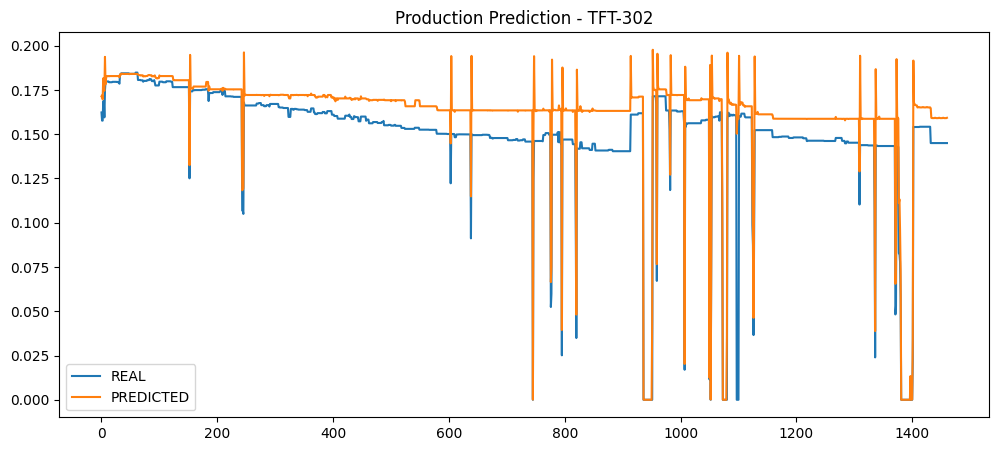

In [15]:
#visualisation
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="REAL")
plt.plot(y_pred, label="PREDICTED")
plt.legend()
plt.title("Production Prediction - TFT-302")
plt.show()

In [16]:
#features importance 

import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
print(importance.head(10))


===== FEATURE IMPORTANCE =====
W_GAS_mean_3     0.797317
HOURS            0.149596
W_GAS_mean_7     0.016761
W_GAS_diff_1     0.009490
W_GAS_lag_7      0.006250
W_GAS_lag_1      0.005978
W_GAS_lag_5      0.003408
W_GAS_lag_2      0.003356
PRESSURE_TEMP    0.002273
W_GAS_lag_3      0.001332
dtype: float64


In [17]:
print(X_test.iloc[0])
print(y_test.iloc[0])

HOURS              24.000000
WHP                49.599998
WHT                59.000000
DELTA_DAYS          1.000000
W_GAS_lag_1         0.164923
WHP_lag_1          48.799999
WHT_lag_1          59.000000
W_GAS_lag_2         0.164923
WHP_lag_2          48.799999
WHT_lag_2          59.000000
W_GAS_lag_3         0.184743
WHP_lag_3          40.900002
WHT_lag_3          59.000000
W_GAS_lag_5         0.184743
WHP_lag_5          40.900002
WHT_lag_5          59.000000
W_GAS_lag_7         0.184743
WHP_lag_7          40.900002
WHT_lag_7          59.000000
W_GAS_mean_3        0.164045
W_GAS_mean_7        0.175872
W_GAS_diff_1       -0.002632
WHP_diff_1          0.799999
PRESSURE_TEMP    2926.399910
DAY_OF_WEEK         0.000000
Name: 5847, dtype: float64
0.16229062


In [18]:
y_pred_naive = X_test["W_GAS_lag_1"]

from sklearn.metrics import mean_absolute_error
mae_naive = mean_absolute_error(y_test, y_pred_naive)

print("Naive MAE:", mae_naive)

Naive MAE: 0.003327791916495551
